In [2]:
import pandas as pd

In [3]:
#pip install numpy scikit-learn statsmodels

In [4]:
import sklearn
import statsmodels
import numpy
print("All packages installed successfully")

All packages installed successfully


In [5]:
from nsepy import get_history as gh
import datetime as dt

In [6]:
#pip install yfinance

In [7]:
import yfinance as yf
import pandas as pd
import datetime as dt

start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-07-01  950.199158  961.612655  948.863025  959.280142    12534407
2021-07-02  964.284851  966.028605  947.934503  949.768825    14086620
2021-07-05  973.864075  975.381346  965.394491  967.636435    11702287
2021-07-06  962.359985  973.275293  960.276598  971.486314    10070124
2021-07-07  955.679382  963.696060  950.221759  963.696060    10454892


In [8]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [9]:
stk_data

Price,Open,High,Low,Close
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2021-07-01,959.280142,961.612655,948.863025,950.199158
2021-07-02,949.768825,966.028605,947.934503,964.284851
2021-07-05,967.636435,975.381346,965.394491,973.864075
2021-07-06,971.486314,973.275293,960.276598,962.359985
2021-07-07,963.696060,963.696060,950.221759,955.679382
...,...,...,...,...
2022-01-20,1132.317646,1136.801534,1111.913611,1122.081665
2022-01-21,1110.554969,1133.314040,1110.554969,1122.262817


In [10]:
column="Close"

In [11]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (144, 1)


In [12]:
len(data1)

144

In [13]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [14]:
from statsmodels.tsa.ar_model import AutoReg

ar_model = AutoReg(y_train.flatten(), lags=5)
model_fit = ar_model.fit()

y_pred = model_fit.predict(start=len(y_train), end=len(data1) - 1)
y_pred = y_pred.reshape(-1, 1)  # match y_test's (n, 1) shape

In [17]:
len(y_pred)

29

In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmsemape(y_Test,predicted_stock_price_test_ori):
    print("RMSE-Testset:",np.sqrt(mean_squared_error(y_Test,predicted_stock_price_test_ori)))

In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = np.sqrt(mean_squared_error(y_test, y_pred))
print(mse)

0.0960664315673089


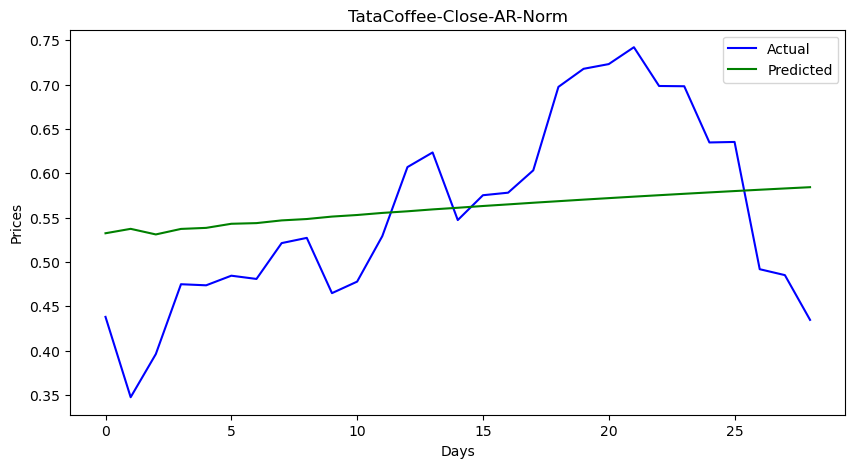

In [20]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [21]:
len(data1)

144

In [22]:
y_test

array([[0.43808821],
       [0.34749852],
       [0.39616686],
       [0.47491208],
       [0.47369168],
       [0.48453129],
       [0.4808705 ],
       [0.52128319],
       [0.52716963],
       [0.46486259],
       [0.47785511],
       [0.52910741],
       [0.6069913 ],
       [0.62350183],
       [0.5472686 ],
       [0.57526415],
       [0.57813521],
       [0.60333051],
       [0.69743783],
       [0.71782352],
       [0.72313537],
       [0.74215788],
       [0.69844231],
       [0.69815521],
       [0.6347721 ],
       [0.63534631],
       [0.4918525 ],
       [0.48517747],
       [0.43471375]])

In [23]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [24]:
aTestNormTable

,Close
0,0.438088
1,0.347499
2,0.396167
3,0.474912
4,0.473692
5,0.484531
6,0.48087
7,0.521283
8,0.52717
9,0.464863


In [25]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [26]:
actual_stock_price_test_ori

array([[1060.03186035],
       [1031.45263672],
       [1046.80651855],
       [1071.64904785],
       [1071.26403809],
       [1074.68371582],
       [1073.52880859],
       [1086.27819824],
       [1088.13525391],
       [1068.4786377 ],
       [1072.57751465],
       [1088.74658203],
       [1113.31738281],
       [1118.52612305],
       [1094.47607422],
       [1103.30810547],
       [1104.21386719],
       [1112.16247559],
       [1141.85144043],
       [1148.28271484],
       [1149.95849609],
       [1155.9597168 ],
       [1142.16833496],
       [1142.07775879],
       [1122.08166504],
       [1122.26281738],
       [1076.9934082 ],
       [1074.88757324],
       [1058.96728516]])

In [27]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [28]:
actual_stock_price_test_oriA

,Close
0,1060.03186
1,1031.452637
2,1046.806519
3,1071.649048
4,1071.264038
5,1074.683716
6,1073.528809
7,1086.278198
8,1088.135254
9,1068.478638


In [29]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [30]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

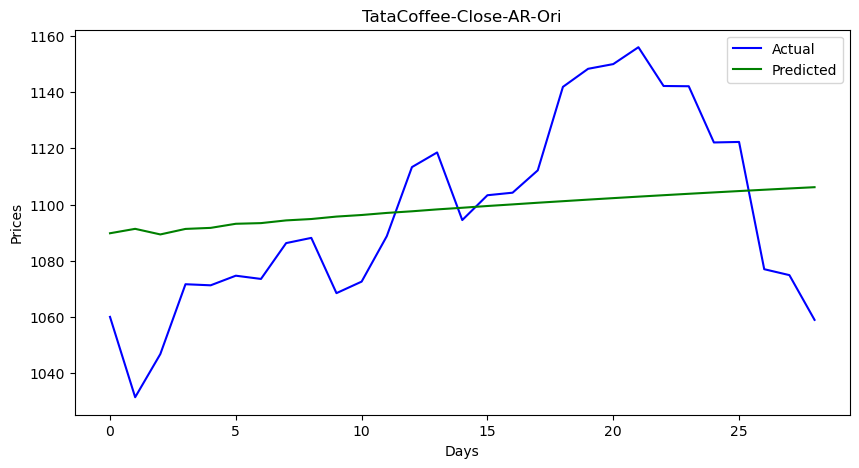

In [31]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [32]:
def rmsemape(y_Test,predicted_stock_price_test_ori):
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import mean_absolute_percentage_error
    import numpy as np
    
    print("RMSE-Testset:", np.sqrt(mean_squared_error(y_Test,predicted_stock_price_test_ori)))
    print("MAPE-Testset:", mean_absolute_percentage_error(y_Test,predicted_stock_price_test_ori))

In [33]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [34]:
forecast

array([0.58572073, 0.58707894, 0.58840775, 0.58970616])

In [35]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [36]:
forecast_stock_price_test_oriF

,Closefore
0,1106.606946
1,1107.035434
2,1107.454647
3,1107.864269


In [37]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

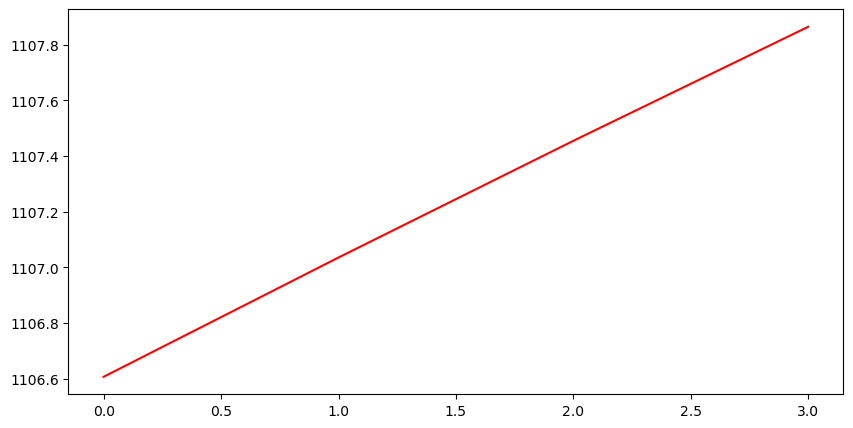

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")